In [13]:
# Cell 1: Import Libraries
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import filters, morphology, measure
import geopandas as gpd
from shapely.geometry import Polygon
import warnings
warnings.filterwarnings('ignore')

# Display settings for better visualization
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Cell 2: Define Data Loading Function
def load_sentinel1_image(file_path):
    """
    Load Sentinel-1 GRD product (converted to GeoTIFF)
    
    Parameters:
    file_path: path to Sentinel-1 GeoTIFF file (VV or VH polarization)
    """
    with rasterio.open(file_path) as src:
        image_db = src.read(1)
        profile = src.profile
        transform = src.transform
        bounds = src.bounds
    
    # Convert to decibels (dB) if image is in linear scale
    # Avoid log of zero or negative values
    # image_abs = np.abs(image)
    # image_abs[image_abs == 0] = 1e-10
    #image_db = 10 * np.log10(image)
    
    print(f"Image shape: {image_db.shape}")
    print(f"Image bounds: {bounds}")
    print(f"CRS: {profile['crs']}")
    # print(image_db.min(), image_db.max())
    # print(image_abs)

    
    
    
    return image_db, profile, transform, bounds
image_db, profile, transform, bounds = load_sentinel1_image("/home/desy/rift-waters/dataset/bogoria/raw/sentinel1/2020-01-31_VV_ASCENDING.tif")


print(image_db.min(), image_db.max())
print("Data loading function defined")

Image shape: (2340, 1766)
Image bounds: BoundingBox(left=36.021634409437105, bottom=0.15352208205602622, right=36.18027688861261, top=0.36372785853999423)
CRS: EPSG:4326
-26.847216472015422 5.22890419663699
Data loading function defined


In [15]:
# Cell 3: Define Speckle Filter (Lee Filter)
def apply_lee_filter(image, window_size=5):
    """
    Apply Lee filter to reduce speckle noise in SAR imagery
    """
    filtered = np.zeros_like(image)
    half_size = window_size // 2
    
    for i in range(half_size, image.shape[0] - half_size):
        for j in range(half_size, image.shape[1] - half_size):
            window = image[i-half_size:i+half_size+1, 
                          j-half_size:j+half_size+1]
            
            mean = np.mean(window)
            variance = np.var(window)
            image_variance = variance - (mean**2) / (window_size**2)
            
            if image_variance < 0:
                image_variance = 0
            
            weight = image_variance / (image_variance + variance + 1e-10)
            filtered[i, j] = mean + weight * (image[i, j] - mean)
    
    print(f"Lee filter applied with window size: {window_size}")
    return filtered


# def lee_filter(da, size):
#     """
#     Apply lee filter of specified window size.
#     Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python

#     """
#     img = da.values
#     img_mean = uniform_filter(img, size)
#     img_sqr_mean = uniform_filter(img**2, size)
#     img_variance = img_sqr_mean - img_mean**2

#     overall_variance = variance(img)

#     img_weights = img_variance / (img_variance + overall_variance)
#     img_output = img_mean + img_weights * (img - img_mean)

#     return img_output

# Faster version using scipy's uniform filter (optional)
def apply_lee_filter_fast(image, window_size=7):
    """Faster implementation of Lee filter using scipy"""
    from scipy import ndimage
    
    mean = ndimage.uniform_filter(image, size=window_size)
    mean_sq = ndimage.uniform_filter(image**2, size=window_size)
    variance = mean_sq - mean**2
    
    overall_variance = ndimage.variance(image)
    
    weights = variance / (variance + overall_variance)
    filtered = mean + weights * (image - mean)
    
    return filtered

print("Speckle filter functions defined")

Speckle filter functions defined


In [16]:
# Cell 4: Define Water Detection Functions
def detect_water_sar(image_db, method='threshold', threshold_value=10):
    """
    Detect water using SAR backscatter properties
    
    Water typically has low backscatter (smooth surface) in SAR imagery
    """
    # Apply speckle filtering
    filtered_image = apply_lee_filter_fast(image_db)
    
    if method == 'threshold':
        # Simple thresholding (water has lower backscatter)
        water_mask = filtered_image < threshold_value
        print(f"Using fixed threshold: {threshold_value} dB")
        
    elif method == 'adaptive_threshold':
        # Otsu's method for automatic threshold selection
        threshold = filters.threshold_otsu(filtered_image)
        water_mask = filtered_image < threshold
        print(f"Using Otsu's threshold: {threshold:.2f} dB")
        
    elif method == 'local_threshold':
        # Local thresholding for heterogeneous areas
        threshold = filters.threshold_local(filtered_image, block_size=51, offset=0)
        water_mask = filtered_image < threshold
        print("Using local adaptive thresholding")
    elif method == 'kmeans':
        from sklearn.cluster import KMeans
        # Reshape for clustering
        pixels = filtered_image.reshape(-1, 1)
        kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)
        labels = kmeans.labels_.reshape(filtered_image.shape)
        # Assume water is the cluster with lower mean backscatter
        cluster_means = [filtered_image[labels == i].mean() for i in range(2)]
        water_cluster = np.argmin(cluster_means)
        water_mask = labels == water_cluster
        print("Using K-means clustering for thresholding")
    elif method == 'minimum_threshold':
        # Minimum error thresholding (Kittler-Illingworth)
        threshold = filters.threshold_minimum(filtered_image)
        water_mask = filtered_image < threshold
        print(f"Using minimum error threshold: {threshold:.2f} dB")
    
    # Apply morphological operations to clean up the mask
    original_count = np.sum(water_mask)
    water_mask = morphology.remove_small_objects(water_mask, min_size=100)
    water_mask = morphology.binary_closing(water_mask, morphology.disk(3))
    water_mask = morphology.binary_opening(water_mask, morphology.disk(2))
    cleaned_count = np.sum(water_mask)
    
    print(f"Mask cleaning: {original_count} -> {cleaned_count} water pixels")
    
    return water_mask

print("Water detection functions defined")

Water detection functions defined


In [17]:
# Cell 5: Define Area Calculation Function
def calculate_water_area(water_mask, transform, pixel_area=100):
    """
    Calculate water surface area in square meters and square kilometers
    """
    water_pixels = np.sum(water_mask)
    
    if pixel_area is None:
        # Calculate pixel area from transform (assuming UTM projection)
        pixel_width = abs(transform[0])
        pixel_height = abs(transform[4])
        pixel_area = pixel_width * pixel_height
        print(f"Pixel size: {pixel_width:.2f}m x {pixel_height:.2f}m")
        print(f"Pixel area: {pixel_area:.2f} m²")
    
    water_area_m2 = water_pixels * pixel_area
    water_area_km2 = water_area_m2 / 1_000_000
    
    return water_area_m2, water_area_km2





water_mask = detect_water_sar(image_db, method='minimum_threshold', threshold_value=-15)

water_area_m2, water_area_km2 = calculate_water_area(water_mask, transform)
print(f"Calculated water area: {water_area_m2:.2f} m², {water_area_km2:.4f} km²")

print("Area calculation function defined")


Using minimum error threshold: -17.65 dB
Mask cleaning: 403552 -> 403514 water pixels
Calculated water area: 40351400.00 m², 40.3514 km²
Area calculation function defined


In [18]:
# Cell 6: Define Water Body Extraction Function
def extract_water_bodies(water_mask):
    """
    Extract individual water bodies as polygons
    """
    # Label connected components
    labeled_mask, num_features = ndimage.label(water_mask)
    
    water_bodies = []
    properties = []
    
    print(f"Found {num_features} individual water bodies")
    
    for i in range(1, num_features + 1):
        # Extract each water body
        water_body_mask = (labeled_mask == i)
        
        # Find contours
        contours = measure.find_contours(water_body_mask, 1)
        
        if contours:
            # Get the largest contour
            main_contour = max(contours, key=len)
            
            # Convert to polygon coordinates
            polygon_coords = [(col, row) for row, col in main_contour]
            
            if len(polygon_coords) >= 3:
                water_bodies.append(polygon_coords)
                area = np.sum(water_body_mask)
                perimeter = len(main_contour)
                compactness = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0
                
                properties.append({
                    'id': i,
                    'pixel_area': area,
                    'perimeter': perimeter,
                    'compactness': compactness
                })
    
    return water_bodies, properties

print("Water body extraction function defined")

Water body extraction function defined


In [19]:
# Cell 7: Define Visualization Function
def visualize_water_detection(image_db, water_mask, bounds, save_path=None):
    """
    Visualize original image and water detection results
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Original SAR image
    im1 = axes[0, 0].imshow(image_db, cmap='gray')
    axes[0, 0].set_title('Original Sentinel-1 SAR Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    plt.colorbar(im1, ax=axes[0, 0], label='Backscatter (dB)', fraction=0.046)
    
    # Histogram of backscatter values
    axes[0, 1].hist(image_db.flatten(), bins=1000, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 1].set_title('Backscatter Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Backscatter (dB)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(x=-15, color='red', linestyle='--', label='Typical water threshold') ## Put minimum threshold
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Water detection mask
    im2 = axes[1, 0].imshow(water_mask, cmap='Blues', interpolation='nearest')
    axes[1, 0].set_title('Water Detection Mask', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    # Overlay water mask on SAR image
    overlay = np.ma.masked_where(~water_mask, image_db)
    axes[1, 1].imshow(image_db, cmap='gray')
    axes[1, 1].imshow(overlay, cmap='Blues', alpha=0.5)
    axes[1, 1].set_title('Water Overlay on SAR Image', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.suptitle('Sentinel-1 Water Surface Detection', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()

def visualize_water_bodies(image_db, water_mask, water_bodies, bounds):
    """
    Visualize individual detected water bodies
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Original image with water overlay
    ax1.imshow(image_db, cmap='gray')
    overlay = np.ma.masked_where(~water_mask, image_db)
    ax1.imshow(overlay, cmap='Blues', alpha=0.5)
    ax1.set_title('All Detected Water Bodies', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Color-coded individual water bodies
    labeled_mask, num_features = ndimage.label(water_mask)
    colors = plt.cm.tab20(np.arange(num_features) % 20)
    
    # Create colored overlay
    colored_overlay = np.zeros((*water_mask.shape, 4))
    for i in range(1, num_features + 1):
        colored_overlay[labeled_mask == i] = colors[i-1]
    
    ax2.imshow(image_db, cmap='gray')
    ax2.imshow(colored_overlay, alpha=0.6)
    ax2.set_title(f'Individual Water Bodies (n={num_features})', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Visualization functions defined")

Visualization functions defined


In [20]:
# Cell 8: Define Save Function
def save_water_mask(water_mask, profile, output_path):
    """
    Save water mask as GeoTIFF
    """
    out_profile = profile.copy()
    out_profile.update({
        'dtype': 'uint8',
        'compress': 'lzw',
        'nodata': 0
    })
    
    with rasterio.open(output_path, 'w', **out_profile) as dst:
        dst.write(water_mask.astype('uint8'), 1)
    
    print(f"Water mask saved to: {output_path}")

print("Save function defined")

Save function defined


In [21]:
# Cell 11: Main Processing Function (Ready for Real Data)
def process_sentinel1_water_detection(sentinel1_file, 
                                     method='threshold',
                                     threshold_value=15,
                                     save_results=True,
                                     visualize=True):
    """
    Main function to process Sentinel-1 image and detect water
    
    Parameters:
    -----------
    sentinel1_file : str
        Path to Sentinel-1 GeoTIFF file
    method : str
        Detection method: 'threshold', 'adaptive_threshold', or 'local_threshold'
    threshold_value : float
        Threshold value for fixed threshold method (in dB)
    save_results : bool
        Whether to save output files
    visualize : bool
        Whether to display visualizations
    """
    
    print("="*60)
    print("SENTINEL-1 WATER SURFACE DETECTION")
    print("="*60)
    
    # Load image
    print(f"\n1. Loading image: {sentinel1_file}")
    image_db, profile, transform, bounds = load_sentinel1_image(sentinel1_file)
    
    # Detect water
    print("\n2. Detecting water bodies...")
    water_mask = detect_water_sar(image_db, method=method, threshold_value=threshold_value)
    
    # Calculate area
    print("\n3. Calculating water surface area...")
    water_area_m2, water_area_km2 = calculate_water_area(water_mask, transform)
    
    # Extract individual water bodies
    print("\n4. Extracting individual water bodies...")
    water_bodies, properties = extract_water_bodies(water_mask)
    
    # Print results
    print("\n" + "="*50)
    print("WATER DETECTION RESULTS")
    print("="*50)
    print(f"Total water surface area: {water_area_m2:,.2f} m²")
    print(f"Total water surface area: {water_area_km2:.4f} km²")
    print(f"Number of water bodies detected: {len(water_bodies)}")
    print(f"Total water pixels: {np.sum(water_mask):,}")
    print(f"Water percentage: {(np.sum(water_mask)/image_db.size)*100:.2f}%")
    
    if properties:
        print("\nIndividual Water Body Statistics:")
        print("-"*40)
        for i, prop in enumerate(properties[:5]):  # Show first 5
            area_pixel = prop['pixel_area']
            area_m2 = area_pixel * abs(transform[0]) * abs(transform[4])
            print(f"Body {prop['id']}: {area_m2:,.2f} m², "
                  f"Compactness: {prop['compactness']:.3f}")
        if len(properties) > 5:
            print(f"... and {len(properties)-5} more water bodies")
    
    # Visualize
    if visualize:
        print("\n5. Generating visualizations...")
        visualize_water_detection(image_db, water_mask, bounds)
        if len(water_bodies) > 1:
            visualize_water_bodies(image_db, water_mask, water_bodies, bounds)
    
    # Save results
    if save_results:
        print("\n6. Saving results...")
        save_water_mask(water_mask, profile, 'water_mask_detected.tif')
        visualize_water_detection(image_db, water_mask, bounds, 
                                 save_path='water_detection_results.png')
    
    print("\n✅ Processing completed successfully!")
    
    return {
        'water_mask': water_mask,
        'area_m2': water_area_m2,
        'area_km2': water_area_km2,
        'num_water_bodies': len(water_bodies),
        'water_bodies': water_bodies,
        'properties': properties
    }

print("Main processing function defined")

Main processing function defined


Processing real Sentinel-1 data...
SENTINEL-1 WATER SURFACE DETECTION

1. Loading image: /home/desy/rift-waters/dataset/bogoria/raw/sentinel1/2020-01-31_VV_ASCENDING.tif
Image shape: (2340, 1766)
Image bounds: BoundingBox(left=36.021634409437105, bottom=0.15352208205602622, right=36.18027688861261, top=0.36372785853999423)
CRS: EPSG:4326

2. Detecting water bodies...
Using K-means clustering for thresholding
Mask cleaning: 408397 -> 407917 water pixels

3. Calculating water surface area...

4. Extracting individual water bodies...
Found 6 individual water bodies

WATER DETECTION RESULTS
Total water surface area: 40,791,700.00 m²
Total water surface area: 40.7917 km²
Number of water bodies detected: 0
Total water pixels: 407,917
Water percentage: 9.87%

5. Generating visualizations...


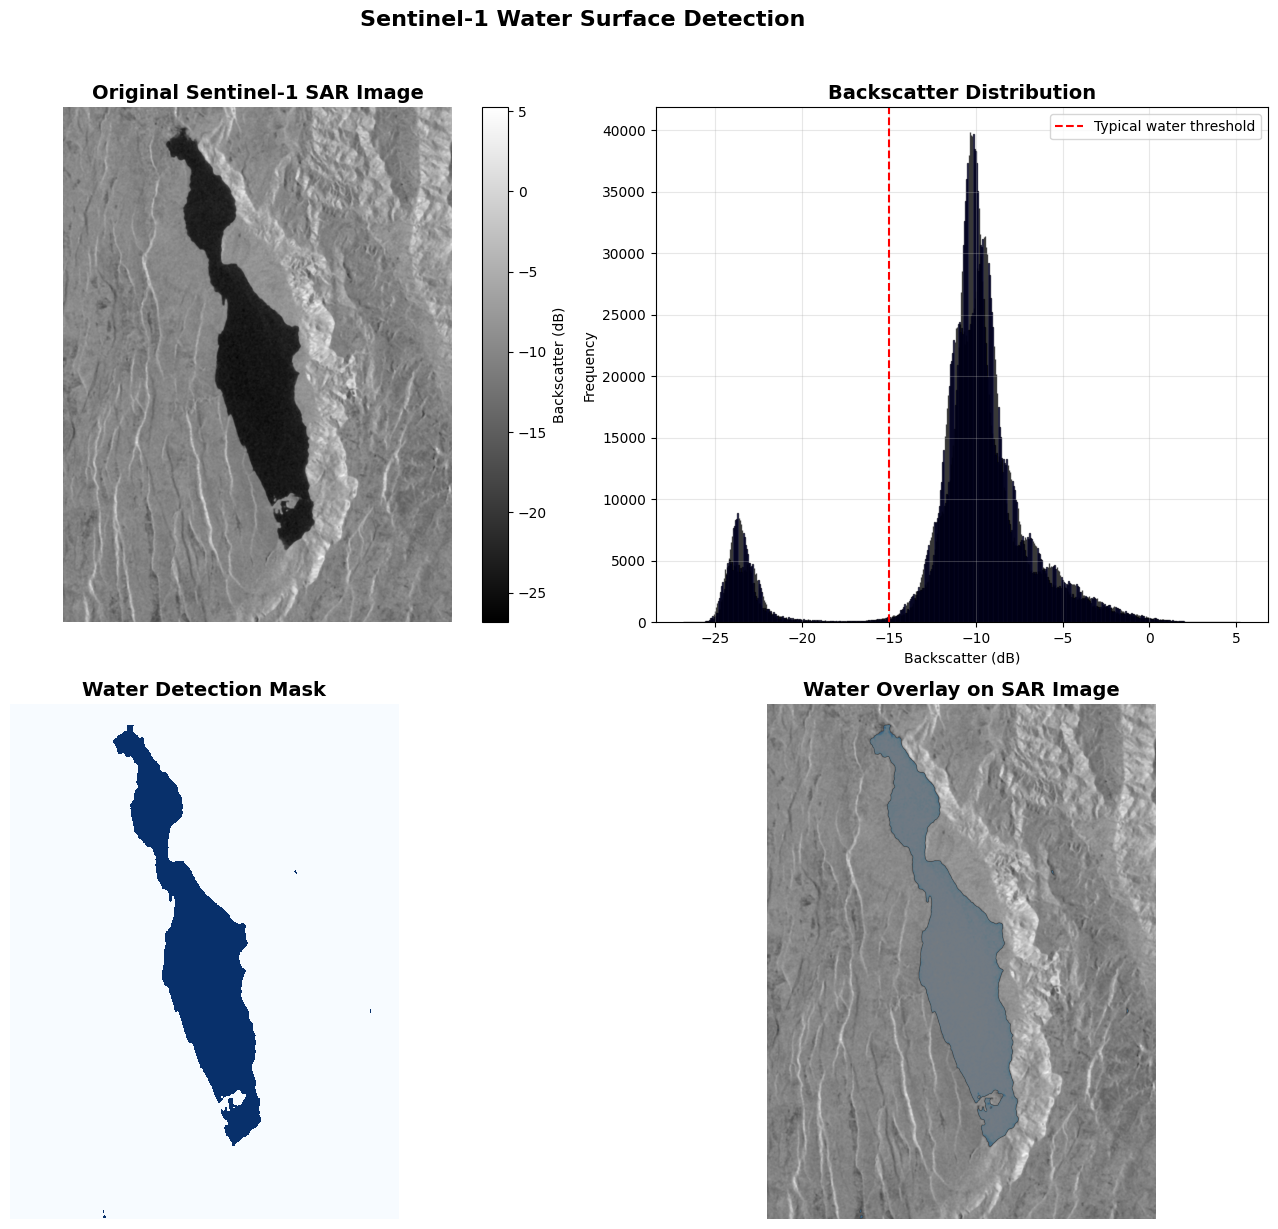


6. Saving results...
Water mask saved to: water_mask_detected.tif
Figure saved to: water_detection_results.png


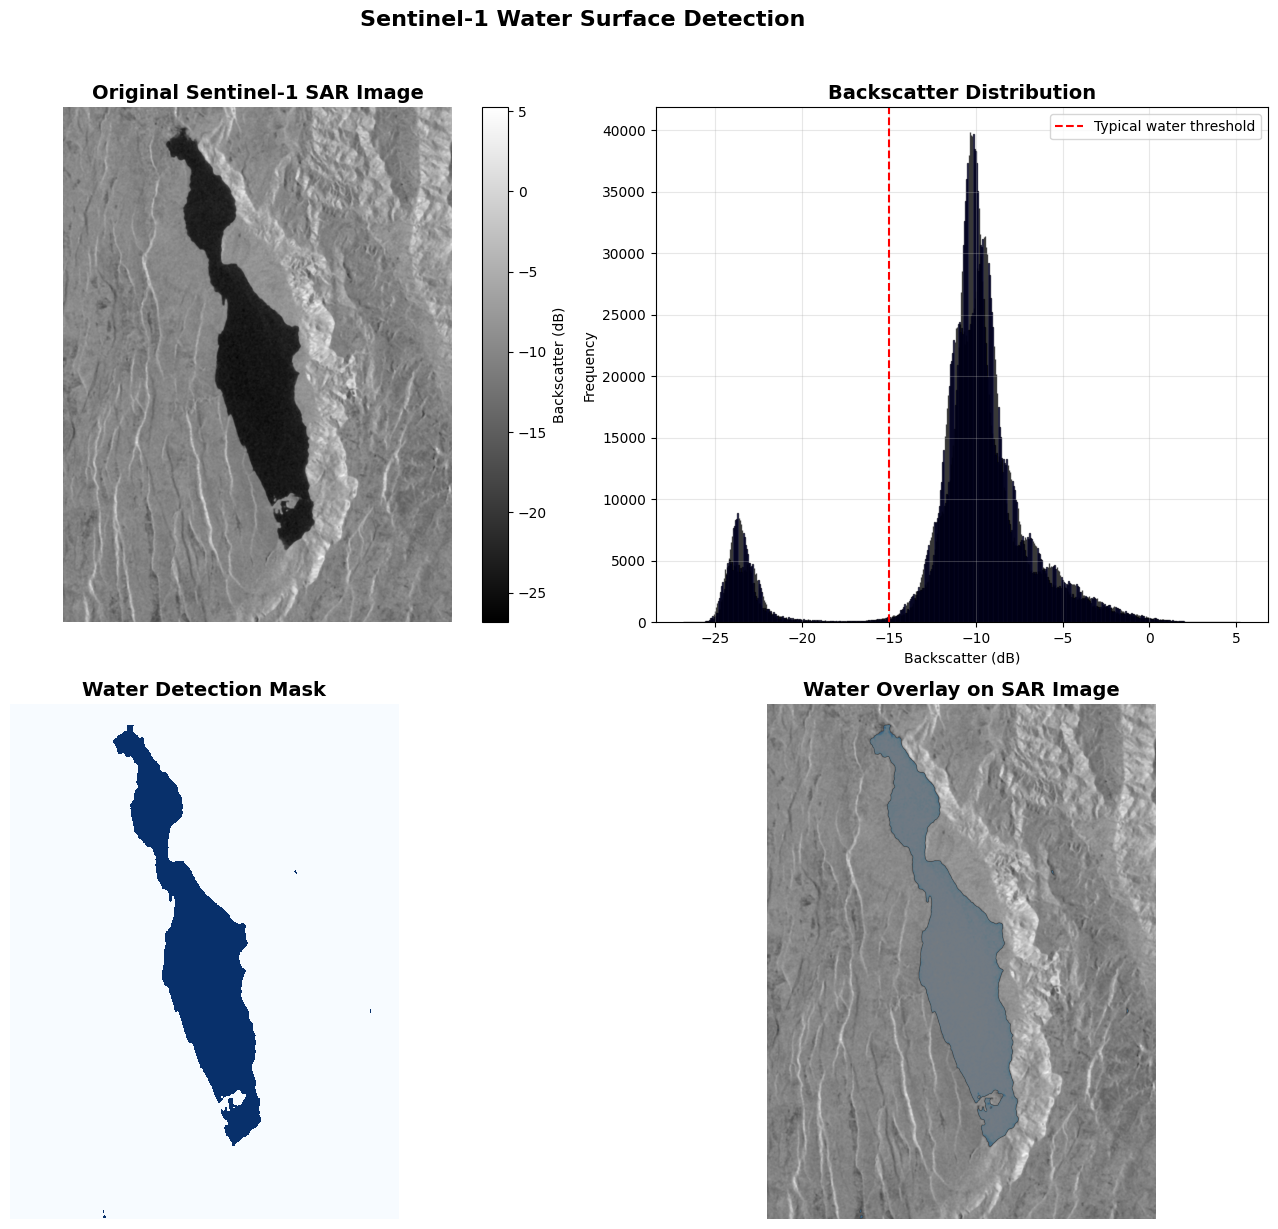


✅ Processing completed successfully!


In [23]:
# Cell 12: Test on Real Data (Update path to your actual Sentinel-1 file)
# Replace this path with your actual Sentinel-1 GeoTIFF file
SENTINEL1_FILE_PATH = "/home/desy/rift-waters/dataset/bogoria/raw/sentinel1/2020-01-31_VV_ASCENDING.tif"

# For testing with synthetic data instead of real data
USE_SYNTHETIC_FOR_TESTING = False  # Set to True when you have real data

if USE_SYNTHETIC_FOR_TESTING:
    print("Using synthetic test data...")
    # Use the synthetic test data we created earlier
    results = process_sentinel1_water_detection(
        sentinel1_file="test_image.tif",  # dummy path
        method='adaptive_threshold',
        save_results=True,
        visualize=True
    )
    # Override with our test data
    results = {
        'water_mask': water_mask_test,
        'area_m2': area_m2,
        'area_km2': area_km2,
        'num_water_bodies': len(water_bodies_test) if 'water_bodies_test' in locals() else 0,
        'water_bodies': water_bodies_test if 'water_bodies_test' in locals() else [],
        'properties': properties_test if 'properties_test' in locals() else []
    }
else:
    print("Processing real Sentinel-1 data...")
    try:
        results = process_sentinel1_water_detection(
            sentinel1_file=SENTINEL1_FILE_PATH,
            method='kmeans',  # Try: 'threshold', 'adaptive_threshold', 'local_threshold'
            threshold_value=-15,  # Only used if method='threshold'
            save_results=True,
            visualize=True
        )
    except FileNotFoundError:
        print(f"❌ File not found: {SENTINEL1_FILE_PATH}")
        print("Please update SENTINEL1_FILE_PATH with your actual file path")
        print("Or set USE_SYNTHETIC_FOR_TESTING = True to test with synthetic data")

In [ ]:
# Cell 13: Compare Different Detection Methods
def compare_detection_methods(sentinel1_file):
    """
    Compare different water detection methods on the same image
    """
    print("COMPARING DIFFERENT DETECTION METHODS")
    print("="*60)
    
    # Load image
    image_db, profile, transform, bounds = load_sentinel1_image(sentinel1_file)
    
    methods = {
        'Fixed Threshold (-15 dB)': ('threshold', -15),
        'Fixed Threshold (-18 dB)': ('threshold', -18),
        'Otsu Adaptive': ('adaptive_threshold', None),
        'Local Adaptive': ('local_threshold', None)
    }
    
    results_dict = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx, (method_name, (method, thresh)) in enumerate(methods.items()):
        print(f"\nTesting: {method_name}")
        
        if method == 'threshold':
            water_mask = detect_water_sar(image_db, method=method, threshold_value=thresh)
        else:
            water_mask = detect_water_sar(image_db, method=method)
        
        water_area_m2, water_area_km2 = calculate_water_area(water_mask, transform)
        
        results_dict[method_name] = {
            'mask': water_mask,
            'area_km2': water_area_km2,
            'water_pixels': np.sum(water_mask)
        }
        
        # Display
        axes[idx].imshow(image_db, cmap='gray', vmin=-25, vmax=0)
        overlay = np.ma.masked_where(~water_mask, image_db)
        axes[idx].imshow(overlay, cmap='Blues', alpha=0.5)
        axes[idx].set_title(f'{method_name}\nArea: {water_area_km2:.2f} km²', fontweight='bold')
        axes[idx].axis('off')
        
        print(f"  → Water area: {water_area_km2:.2f} km²")
        print(f"  → Water pixels: {np.sum(water_mask):,}")
    
    plt.suptitle('Comparison of Water Detection Methods', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*60)
    print("SUMMARY COMPARISON")
    print("="*60)
    print(f"{'Method':<25} {'Area (km²)':<15} {'Water Pixels':<15}")
    print("-"*60)
    for method_name, data in results_dict.items():
        print(f"{method_name:<25} {data['area_km2']:<15.2f} {data['water_pixels']:<15,}")
    
    return results_dict

# Uncomment to run comparison on real data
# if not USE_SYNTHETIC_FOR_TESTING:
#     compare_results = compare_detection_methods(SENTINEL1_FILE_PATH)

In [ ]:
from datetime import datetime, timedelta
from calendar import monthrange
from typing import List, Tuple

def get_month_ranges(start_year: int, end_year: int) -> List[Tuple[datetime, datetime]]:
    """
    Returns start and end dates for each month in the given year range.
    
    Args:
        start_year: Starting year (inclusive)
        end_year: Ending year (inclusive)
    
    Returns:
        List of tuples containing (start_date, end_date) for each month
    """
    month_ranges = []
    
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            # First day of the month
            start_date = datetime(year, month, 1)
            
            # Last day of the month
            last_day = monthrange(year, month)[1]
            end_date = datetime(year, month, last_day)
            
            month_ranges.append((start_date, end_date))
    
    return month_ranges

def format_dates(month_ranges: List[Tuple[datetime, datetime]], 
                 date_format: str = "%Y-%m-%d") -> List[Tuple[str, str]]:
    """
    Formats the date tuples as strings.
    
    Args:
        month_ranges: List of date tuples from get_month_ranges()
        date_format: Format string for datetime.strftime()
    
    Returns:
        List of formatted date string tuples
    """
    return [(start.strftime(date_format), end.strftime(date_format)) 
            for start, end in month_ranges]

def print_month_ranges(start_year: int, end_year: int, 
                       date_format: str = "%Y-%m-%d"):
    """
    Prints start and end dates for each month in the year range.
    
    Args:
        start_year: Starting year (inclusive)
        end_year: Ending year (inclusive)
        date_format: Format string for datetime.strftime()
    """
    month_ranges = get_month_ranges(start_year, end_year)
    formatted_ranges = format_dates(month_ranges, date_format)
    
    print(f"Month ranges from {start_year} to {end_year}:\n")
    
    for start_str, end_str in formatted_ranges:
        print(f"{start_str} to {end_str}")

def get_month_ranges_by_year(start_year: int, end_year: int) -> dict:
    """
    Returns month ranges organized by year.
    
    Args:
        start_year: Starting year (inclusive)
        end_year: Ending year (inclusive)
    
    Returns:
        Dictionary with years as keys and list of month ranges as values
    """
    result = {}
    
    for year in range(start_year, end_year + 1):
        year_ranges = []
        for month in range(1, 13):
            start_date = datetime(year, month, 1)
            last_day = monthrange(year, month)[1]
            end_date = datetime(year, month, last_day)
            year_ranges.append((start_date, end_date))
        result[year] = year_ranges
    
    return result

# Example usage
# Example 1: Simple range (2020-2022)
print("=" * 50)
print("EXAMPLE 1: Basic usage")
print("=" * 50)
month_ranges = get_month_ranges(2020, 2022)

for start, end in month_ranges[:5]:  # Show first 5 months
    print(f"{start.strftime('%Y-%m-%d')} -> {end.strftime('%Y-%m-%d')}")
print("...")

# Example 2: Formatted output
print("\n" + "=" * 50)
print("EXAMPLE 2: Formatted output")
print("=" * 50)
print_month_ranges(2023, 2023)

# Example 3: Different date format
print("\n" + "=" * 50)
print("EXAMPLE 3: Different date format")
print("=" * 50)
print_month_ranges(2024, 2024, date_format="%d/%m/%Y")

# Example 4: Organized by year
print("\n" + "=" * 50)
print("EXAMPLE 4: Month ranges by year")
print("=" * 50)
ranges_by_year = get_month_ranges_by_year(2021, 2022)

for year, ranges in ranges_by_year.items():
    print(f"\n{year}:")
    for start, end in ranges[:3]:  # Show first 3 months
        print(f"  {start.strftime('%b %d, %Y')} -> {end.strftime('%b %d, %Y')}")
    print("  ...")

# Example 5: Working with the data
print("\n" + "=" * 50)
print("EXAMPLE 5: Data manipulation")
print("=" * 50)
    
# Get all months in 2024
all_months_2024 = get_month_ranges(2024, 2024)

# Find month with most days (should be all 31-day months)
longest_month = max(all_months_2024, key=lambda x: (x[1] - x[0]).days + 1)
print(f"Longest month in 2024: {longest_month[0].strftime('%B %Y')} "
        f"({(longest_month[1] - longest_month[0]).days + 1} days)")

# Calculate total days in a year
total_days = sum((end - start).days + 1 for start, end in all_months_2024)
print(f"Total days in 2024: {total_days}")


EXAMPLE 1: Basic usage
2020-01-01 -> 2020-01-31
2020-02-01 -> 2020-02-29
2020-03-01 -> 2020-03-31
2020-04-01 -> 2020-04-30
2020-05-01 -> 2020-05-31
...

EXAMPLE 2: Formatted output
Month ranges from 2023 to 2023:

2023-01-01 to 2023-01-31
2023-02-01 to 2023-02-28
2023-03-01 to 2023-03-31
2023-04-01 to 2023-04-30
2023-05-01 to 2023-05-31
2023-06-01 to 2023-06-30
2023-07-01 to 2023-07-31
2023-08-01 to 2023-08-31
2023-09-01 to 2023-09-30
2023-10-01 to 2023-10-31
2023-11-01 to 2023-11-30
2023-12-01 to 2023-12-31

EXAMPLE 3: Different date format
Month ranges from 2024 to 2024:

01/01/2024 to 31/01/2024
01/02/2024 to 29/02/2024
01/03/2024 to 31/03/2024
01/04/2024 to 30/04/2024
01/05/2024 to 31/05/2024
01/06/2024 to 30/06/2024
01/07/2024 to 31/07/2024
01/08/2024 to 31/08/2024
01/09/2024 to 30/09/2024
01/10/2024 to 31/10/2024
01/11/2024 to 30/11/2024
01/12/2024 to 31/12/2024

EXAMPLE 4: Month ranges by year

2021:
  Jan 01, 2021 -> Jan 31, 2021
  Feb 01, 2021 -> Feb 28, 2021
  Mar 01, 2021 ->